<a href="https://colab.research.google.com/github/MarianoVIsabella/Data-Warehouse-Project/blob/main/DataQuality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

First, we are going to setup our environment

In [1]:
from google.colab import drive
if __name__ == "__main__":
  drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
BASE_PATH = '/content/drive/MyDrive'

In [3]:
!pip install scipy --quiet

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import warnings
import re
from datetime import datetime
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
np.random.seed(42)
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
df_match = pd.read_csv(BASE_PATH + "/matches_1930_2022.csv")

# DQAR Report

Here is the main class we are going to utilize to determine the Data Quality of the dataset, DQAReport, including methods to check Completeness, Uniqueness, Validity, Consistency and Timeliness. The class also generates a score card, storing it in a .csv file, along with a method to display such a card

In [5]:
class DQAReport:

    """
    # Structured, repeatable Data Quality Assessment Report.
    # Evaluates all ISO 25012 dimensions and produces a scoreboard.
    # Specify that the class checks ISO 25012 quality dimensions and returns a summary report.
    """
    def __init__(self, df: pd.DataFrame, table_name: str, primary_key = None):

        self.df         = df.copy()
        self.table_name = table_name
        self.pk         = [primary_key] if isinstance(primary_key, str) else primary_key
        self.results    = {}   # dimension -> {'score': float, 'issues': int, 'details': str}
        # Initialize a dictionary to store the final results for each quality dimension.
        self.flags      = {}   # dimension -> boolean Series (True = issue)
        # Initialize a dictionary to store row-level issue flags for each dimension.
        self.rule_flags = {}

    def check_completeness(self, required_cols: list = None):
        cols = required_cols or self.df.columns.tolist()
        missing_counts = self.df[cols].isnull().sum()
        total_values   = len(self.df) * len(cols)
        total_missing  = missing_counts.sum()
        score          = 1 - (total_missing / total_values)
        flag_rows      = self.df[cols].isnull().any(axis=1)
        self.flags['completeness'] = flag_rows
        self.results['completeness'] = {
            'score'  : round(score, 4),
            'issues' : int(total_missing),
            'details': f"Missing per column: {missing_counts[missing_counts > 0].to_dict()}"
        }

        return self

    def check_uniqueness(self, key_cols: list = None):
        cols = key_cols or (self.pk if self.pk else self.df.columns.tolist())
        dup    = self.df.duplicated(subset=cols, keep=False)
        score  = 1 - (dup.sum() / len(self.df))
        self.flags['uniqueness'] = dup
        self.results['uniqueness'] = {
            'score'  : round(score, 4),
            'issues' : int(dup.sum()),
            'details': f"Duplicate rows on {cols}: {int(dup.sum())}"
        }
        return self

    def check_validity(self, rules: dict):
        """
        # Document the expected structure of the input parameter.
        rules: {col_name: callable -> bool Series}
        # Each key is a column name and each value is a function returning a boolean Series.
        callable returns True for VALID rows
        # The function must return True for valid values and False for invalid ones.
        """

        all_invalid = pd.Series(False, index=self.df.index)
        rule_details = []

        for col, rule_fn in rules.items():
            if col not in self.df.columns:
                continue
            valid_mask   = rule_fn(self.df[col])
            # Apply the validation function to the column and get a boolean mask of valid rows.
            invalid_mask = ~valid_mask & self.df[col].notna()
            # Mark invalid values while excluding missing values from validity errors.
            all_invalid |= invalid_mask
            # Update the cumulative invalid-row mask using logical OR.
            rule_details.append(f"{col}: {int(invalid_mask.sum())} invalid")
            # Add a summary string reporting the number of invalid values for the current column.

        score = 1 - (all_invalid.sum() / len(self.df))
        self.flags['validity'] = all_invalid

        self.results['validity'] = {
            'score'  : round(score, 4),
            'issues' : int(all_invalid.sum()),
            'details': " | ".join(rule_details)
        }

        return self

    def check_consistency(self, rules: list, rule_names: list = None):

    #rules: list of callables that return bool Series
      #     True = row is CONSISTENT
    #rule_names: optional list of labels, same length as rules,
     #           used for reporting. Defaults to "rule_0", "rule_1", ...

      names = rule_names or [f"rule_{i}" for i in range(len(rules))]
      if len(names) != len(rules):
          raise ValueError("rule_names must have the same length as rules")

      per_rule_flags = {}
      all_inconsistent = pd.Series(False, index=self.df.index)

      for name, rule_fn in zip(names, rules):
          inconsistent = ~rule_fn(self.df)
          per_rule_flags[name] = inconsistent
          all_inconsistent |= inconsistent

      score = 1 - (all_inconsistent.sum() / len(self.df))
      self.flags['consistency'] = all_inconsistent
      self.rule_flags = per_rule_flags

      per_rule_counts = {name: int(flag.sum()) for name, flag in per_rule_flags.items()}

      self.results['consistency'] = {
          'score'  : round(score, 4),
          'issues' : int(all_inconsistent.sum()),
          'details': " | ".join(f"{name}: {count} violations" for name, count in per_rule_counts.items())
      }

      return self


    def check_timeliness(self, date_col: str, max_age_days: int = 365, allow_future: bool = False):
        if date_col not in self.df.columns:
            return self

        now  = pd.Timestamp.now()
        col  = pd.to_datetime(self.df[date_col], errors='coerce')
        stale  = (now - col).dt.days > max_age_days
        future = col > now if not allow_future else pd.Series(False, index=col.index)
        flag   = stale | future
        score  = 1 - (flag.sum() / len(self.df))
        self.flags['timeliness'] = flag
        self.results['timeliness'] = {
            'score'  : round(score, 4),
            'issues' : int(flag.sum()),
            'details': f"Future dates: {int(future.sum())} | Stale (>{max_age_days}d): {int(stale.sum())}"
        }

        return self

    def scorecard(self) -> pd.DataFrame:
        rows = []
        for dim, res in self.results.items():
            emoji = '🟢' if res['score'] >= 0.95 else ('🟡' if res['score'] >= 0.80 else '🔴')
            rows.append({
                'Table'    : self.table_name,
                'Dimension': dim.capitalize(),
                'Score'    : res['score'],
                'Issues'   : res['issues'],
                'Status'   : emoji,
                'Details'  : res['details']
            })

        return pd.DataFrame(rows)

    def overall_score(self) -> float:
        if not self.results:
            return 0.0 # default return value for robustness

        return round(np.mean([v['score'] for v in self.results.values()]), 4)

    def color_score(self,val):
        if val >= 0.95:
            color = '#2ecc71'
        elif val >= 0.80:
            color = '#f1c40f'
        else:
            color = '#e74c3c'
        return f'background-color: {color}; color: white; font-weight: bold'

    def display_scorecard(self,df: pd.DataFrame, title: str, overall_score: float):

      styled = (
          df.style
          .format({'Score': '{:.2%}'})
          .applymap(self.color_score, subset=['Score'])
          .set_properties(**{'text-align': 'left', 'padding': '8px', 'font-size': '13px'})
          .set_table_styles([
              {'selector': 'th', 'props': [
                  ('background-color', '#54D98C'),
                  ('color', 'white'),
                  ('font-weight', 'bold'),
                  ('text-align', 'center'),
                  ('padding', '10px'),
              ]},
              {'selector': 'td', 'props': [('border', '1px solid #ddd')]},
              {'selector': 'tr:nth-of-type(even)', 'props': []},
              {'selector': 'caption', 'props': [
                  ('caption-side', 'top'),
                  ('font-size', '16px'),
                  ('font-weight', 'bold'),
                  ('padding', '10px'),
                  ('text-align', 'left'),
              ]},
          ])
          .set_caption(f'{title} — Overall DQ Score: {overall_score:.2%}')
          .hide(axis='index')
      )
      return styled

The analysis we are going to do will start from the .csv file, in order to understand the issues of the .csv file and (in the Data Cleaning Colab) solve them before the loading phase on reconciled database. This way data will be already cleaned and easier to process through the ETL pipeline.

In [6]:
#parsing function we are going to need for some consistency rules

def parse_score(score_series):
    pattern = r'^(?:\((\d+)\)\s*)?(\d+)\s*[-–]\s*(\d+)(?:\s*\((\d+)\))?\s*$'
    #although later it will be stated that the score should not have space at the end of the string, the regex still considers it
    #(optional) to enable robust consistency check
    extracted = score_series.astype(str).str.extract(pattern)
    home_penalty = pd.to_numeric(extracted[0], errors='coerce')
    home     = pd.to_numeric(extracted[1], errors='coerce')
    away     = pd.to_numeric(extracted[2], errors='coerce')
    away_penalty = pd.to_numeric(extracted[3], errors='coerce')

    return home_penalty, home, away, away_penalty

In [7]:


key_fields=['home_team', 'away_team', 'Date'] #columns composing the primary key
#columns that should NOT have any null value
required=['home_team', 'away_team', 'home_score', 'away_score', 'home_manager', 'away_manager','Attendance', 'Round', 'Date', 'Year']
#Compute the oldest date that should be tolerated in the dataset (1930, year of the first world Cup Edition)
current_year= datetime.today().year
range_len= (current_year - 1930) + 1 #the +1 guarantees that all dates from the very first year are always taken.

match_validity_rules = {
    'home_score' : lambda s: s >= 0,
    'away_score' : lambda s: s >= 0,
    'Attendance' : lambda s: s.between(1, 200000),
    'home_xg' : lambda s: s.between (0, 12),
    'away_xg' : lambda s: s.between (0, 12),
    'home_penalty' : lambda s: s >= 0,
    'away_penalty' : lambda s: s >= 0,
    'Year': lambda s: s.isin([1930,1934,1938] + [x for x in range(1950,current_year,4)]), #check the year is one of the real year of World Cup editions
                                                                                          #(every 4 year starting from 1930, excluded 1942 and 1946)
    'Round': lambda s: s.isin(['Second round', 'Round of 16', 'Quarter-finals', 'Second group stage', 'First group stage', 'Group stage', 'Final stage', 'Semi-finals', 'First round', 'Third-place match', 'Final', 'Group stage play-off']),
    'Date' : lambda s: pd.to_datetime(s, errors='coerce').notna(), # All dates should be in a valid format
    'Score' : lambda s: s == s.str.strip() #No space at the beginning or at the end of the value
}

match_consistency_rules = [
    lambda df: (lambda hp, h, a, ap: (
        (df['home_score'] == h) & (df['away_score'] == a)
    ))(*parse_score(df['Score'])),
    lambda df: ~(df['home_penalty'].notna()) | (lambda hp, h, a, ap: (
        df['home_penalty'] == hp
    ))(*parse_score(df['Score'])),
    lambda df: ~(df['away_penalty'].notna()) | (lambda hp, h, a, ap: (
        df['away_penalty'] == ap
    ))(*parse_score(df['Score'])),
    lambda df: df['home_penalty'].notna() == df['away_penalty'].notna(),
    lambda df: ~(df['home_penalty'] > 0) | df['home_penalty_shootout_goal_long'].notna(),
    lambda df: ~(df['away_penalty'] > 0) | df['away_penalty_shootout_goal_long'].notna(),
    lambda df: ~(df['home_penalty'] == 0) | df['home_penalty_shootout_miss_long'].notna(),
    lambda df: ~(df['away_penalty'] == 0) | df['away_penalty_shootout_miss_long'].notna(),
    lambda df: df['home_xg'].notna() == df['away_xg'].notna(),
    lambda df: df['Year'] == pd.to_datetime(df['Date'], errors = 'coerce').dt.year,
    lambda df: ~(df['home_score'] > 0) | ((df['home_goal'].notna() & df['home_goal_long'].notna()) | (df['home_penalty_goal'].notna()) | (df['home_own_goal'].notna())),
    lambda df: ~(df['away_score'] > 0) | ((df['away_goal'].notna() & df['away_goal_long'].notna()) | (df['away_penalty_goal'].notna()) | (df['away_own_goal'].notna())),
    lambda df: df['home_team'] != df['away_team'],
    lambda df: df['home_captain'] != df['away_captain'],
    lambda df: df['home_manager'] != df['away_manager']
]
    #Note on the last two rules:
    #If the home_score is bigger than 0, then at least one between the home_goal(and its long description),the
    #home_penalty_goal and the home_own_goal must be NOT null.
    #Same reasoning applies on the away columns



Having defined all the parameters necessary, we can now produce the DQAReport and see the score of the dataset for each of the data quality dimensions, according to the ISO 25012

In [8]:
dqa_match = (
    DQAReport(df_match, table_name='match_fact', primary_key=key_fields)
    .check_completeness(required_cols=required)
    .check_uniqueness(key_cols=key_fields)
    .check_validity(match_validity_rules)
    .check_consistency(match_consistency_rules)
    .check_timeliness('Date', max_age_days=365 * range_len, allow_future=False)
)
scorecard_match = dqa_match.scorecard()
scorecard_match.to_csv(BASE_PATH + '/dq_scorecard_match.csv', index=False)

dqa_match.display_scorecard(
    scorecard_match[['Dimension', 'Score', 'Issues', 'Status', 'Details']],
    'MATCH DATASET',
    dqa_match.overall_score()
)

Dimension,Score,Issues,Status,Details
Completeness,100.00%,0,🟢,Missing per column: {}
Uniqueness,100.00%,0,🟢,"Duplicate rows on ['home_team', 'away_team', 'Date']: 0"
Validity,99.90%,1,🟢,home_score: 0 invalid | away_score: 0 invalid | Attendance: 0 invalid | home_xg: 0 invalid | away_xg: 0 invalid | home_penalty: 0 invalid | away_penalty: 0 invalid | Year: 0 invalid | Round: 0 invalid | Date: 0 invalid | Score: 1 invalid
Consistency,100.00%,0,🟢,rule_0: 0 violations | rule_1: 0 violations | rule_2: 0 violations | rule_3: 0 violations | rule_4: 0 violations | rule_5: 0 violations | rule_6: 0 violations | rule_7: 0 violations | rule_8: 0 violations | rule_9: 0 violations | rule_10: 0 violations | rule_11: 0 violations | rule_12: 0 violations | rule_13: 0 violations | rule_14: 0 violations
Timeliness,100.00%,0,🟢,Future dates: 0 | Stale (>35405d): 0


Speaking of missing values, the completeness checked only for **required** columns, the columns where there should not be a NULL. To check for missing values in every column, we can exploit a Missing Value Matrix

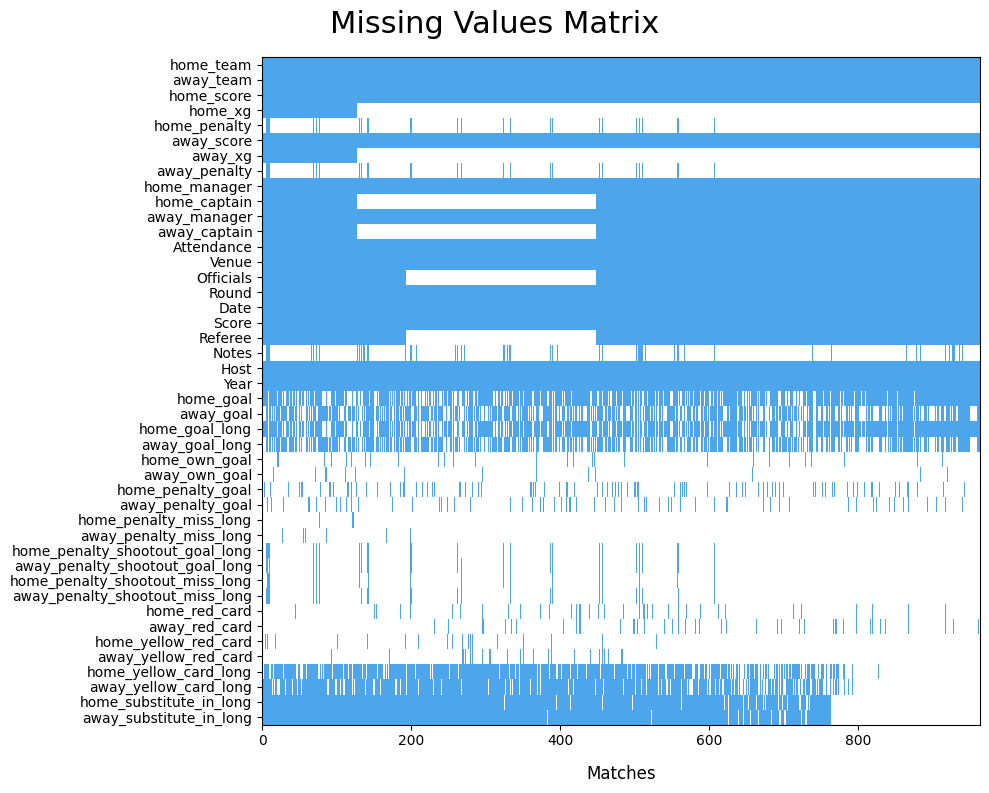

In [9]:
if __name__ == "__main__":
  presence = (~df_match.isna()).astype(int).T.values
  fig, ax = plt.subplots(figsize=(10, 8))

  cmap = ListedColormap([
      "#ffffff",   # Missing value
      "#4da6eb" # Present value
      ])

  im = ax.imshow(
      presence,
      aspect="auto",
      interpolation="nearest",
      cmap=cmap,
      vmin=0,
      vmax=1,
      origin="upper"
  )

  ax.set_yticks(np.arange(len(df_match.columns)))
  ax.set_yticklabels(df_match.columns, fontsize=10)

  ax.set_xlabel(
      "Matches",
      fontsize=12,
      labelpad=12
  )

  fig.suptitle(
      "Missing Values Matrix",
      fontsize=22,
      y=0.985)

  ax.grid(False)

  plt.tight_layout()
  plt.savefig(BASE_PATH + "/dq_match_plot_inverted.png", dpi=300)
  plt.show()

# Finding outliers

We need now to address accuracy, that is to check if there is any outlier or unrealistic value.




To do so, we define the OutlierDetector class, a class that checks for outliers by a consensus strategy, exploiting five different methods:


1.   IQR Fence
2.   Z-Score
3.   Modified Z-Score
4.   Isolation Forest
5.   Local Outlier Factor



In [10]:
class OutlierDetector:

    """
    Structured, repeatable outlier detection for DW tables.
    Supports univariate (IQR, Z-score, Modified Z-score) and
    multivariate (Isolation Forest, LOF) methods.
    """

    def __init__(self, df: pd.DataFrame, table_name: str):
        self.df         = df.copy()
        self.table_name = table_name
        self.flags      = pd.DataFrame(False, index=df.index,
                                       columns=['iqr','zscore','mod_zscore',
                                                'isolation_forest','lof'])
        self.results    = {}

    def detect_iqr(self, cols: list, multiplier: float = 1.5):
        flag = pd.Series(False, index=self.df.index)
        details = {}

        for col in cols:
            if col not in self.df.columns: continue
            s  = self.df[col].dropna()
            Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
            IQR    = Q3 - Q1
            lo, hi = Q1 - multiplier * IQR, Q3 + multiplier * IQR
            col_flag = ((self.df[col] < lo) | (self.df[col] > hi)) & self.df[col].notna()
            flag |= col_flag
            details[col] = {'Q1': round(Q1,2), 'Q3': round(Q3,2), 'IQR': round(IQR,2),
                            'lower_fence': round(lo,2), 'upper_fence': round(hi,2),
                            'outlier_count': int(col_flag.sum())}

        self.flags['iqr'] = flag
        self.results['iqr'] = {'total_flagged': int(flag.sum()),
                               'pct': round(flag.mean()*100, 2), 'details': details}
        return self


    def detect_zscore(self, cols: list, threshold: float = 3.0):
        flag = pd.Series(False, index=self.df.index)
        details = {}
        for col in cols:
            if col not in self.df.columns: continue
            s         = self.df[col].fillna(self.df[col].mean())
            z         = np.abs(stats.zscore(s))
            col_flag  = pd.Series(z > threshold, index=self.df.index) & self.df[col].notna()
            flag |= col_flag
            details[col] = {'mean': round(self.df[col].mean(), 2),
                            'std' : round(self.df[col].std(), 2),
                            'max_z': round(z.max(), 2),
                            'outlier_count': int(col_flag.sum())}
        self.flags['zscore'] = flag
        self.results['zscore'] = {'total_flagged': int(flag.sum()),
                                  'pct': round(flag.mean()*100, 2), 'details': details}
        return self

    def detect_modified_zscore(self, cols: list, threshold: float = 3.5):
        flag = pd.Series(False, index=self.df.index)
        details = {}
        for col in cols:
            if col not in self.df.columns: continue
            s      = self.df[col].dropna()
            median = s.median()
            mad    = (s - median).abs().median()
            if mad == 0: continue
            mod_z  = 0.6745 * (self.df[col] - median) / mad
            col_flag = (mod_z.abs() > threshold) & self.df[col].notna()
            flag |= col_flag
            details[col] = {'median': round(median, 2), 'MAD': round(mad, 2),
                            'max_mod_z': round(mod_z.abs().max(), 2),
                            'outlier_count': int(col_flag.sum())}

        self.flags['mod_zscore'] = flag
        self.results['mod_zscore'] = {'total_flagged': int(flag.sum()),
                                      'pct': round(flag.mean()*100, 2), 'details': details}

        return self

    def detect_isolation_forest(self, cols: list,
                                 contamination: float = 0.05,
                                 n_estimators: int = 100):

        valid_cols = [c for c in cols if c in self.df.columns
                      and pd.api.types.is_numeric_dtype(self.df[c])]
        X = self.df[valid_cols].fillna(self.df[valid_cols].median())
        X_scaled = StandardScaler().fit_transform(X)
        model  = IsolationForest(n_estimators=n_estimators,
                                 contamination=contamination,
                                 random_state=42)
        preds  = model.fit_predict(X_scaled)
        scores = model.decision_function(X_scaled)
        flag   = pd.Series(preds == -1, index=self.df.index)
        self.flags['isolation_forest'] = flag
        self.results['isolation_forest'] = {
            'total_flagged': int(flag.sum()),
            'pct': round(flag.mean()*100, 2),
            'cols_used': valid_cols,
            'min_score': round(scores.min(), 4),
            'mean_score': round(scores.mean(), 4)
        }
        self._if_scores = scores
        return self

    def detect_lof(self, cols: list, n_neighbors: int = 20,
                   contamination: float = 0.05):

        valid_cols = [c for c in cols if c in self.df.columns
                      and pd.api.types.is_numeric_dtype(self.df[c])]
        X = self.df[valid_cols].fillna(self.df[valid_cols].median())
        X_scaled = StandardScaler().fit_transform(X)
        model  = LocalOutlierFactor(n_neighbors=n_neighbors,
                                    contamination=contamination)
        preds  = model.fit_predict(X_scaled)
        flag   = pd.Series(preds == -1, index=self.df.index)
        self.flags['lof'] = flag
        self.results['lof'] = {
            'total_flagged': int(flag.sum()),
            'pct': round(flag.mean()*100, 2),
            'cols_used': valid_cols,
        }

        return self
    def consensus(self, min_methods: int = 3) -> pd.Series:
        count = self.flags.sum(axis=1)
        return count >= min_methods

    def scorecard(self) -> pd.DataFrame:
        rows = []
        for method, res in self.results.items():
            rows.append({
                'Method': method.replace('_',' ').title(),
                'Flagged': res['total_flagged'],
                'Pct (%)': res['pct'],
                'Type': 'Multivariate' if method in ('isolation_forest','lof') else 'Univariate'
            })

        df = pd.DataFrame(rows)
        consensus = self.consensus()
        df.loc[len(df)] = {'Method': 'CONSENSUS (≥3 methods)',
                           'Flagged': int(consensus.sum()),
                           'Pct (%)': round(consensus.mean()*100, 2),
                           'Type': 'Combined'}
        return df

In [11]:
if __name__ == "__main__":
  measures = ['home_score', 'away_score','home_penalty','away_penalty', 'home_xg','away_xg','Attendance'] #Numeric measures where to check for outliers
  od_match = (
      OutlierDetector(df_match, 'match_data')
      .detect_iqr(measures, multiplier=1.5)
      .detect_zscore(measures, threshold=3.0)
      .detect_modified_zscore(measures, threshold=3.5)
      .detect_isolation_forest(measures, contamination=0.04)
      .detect_lof(measures, n_neighbors=20, contamination=0.04)
  )
  print('Outlier Detection Scorecard — match fact measures:')
  print(od_match.scorecard().to_string(index=False))
  print('\n Details per column for IQR:')
  for col, det in od_match.results['iqr']['details'].items():
        print(f"   {col:<18}: fence=[{det['lower_fence']}, {det['upper_fence']}], "
              f"outliers={det['outlier_count']}")

Outlier Detection Scorecard — match fact measures:
                Method  Flagged  Pct (%)         Type
                   Iqr       39    4.050   Univariate
                Zscore      114   11.830   Univariate
            Mod Zscore       30    3.110   Univariate
      Isolation Forest       39    4.050 Multivariate
                   Lof       39    4.050 Multivariate
CONSENSUS (≥3 methods)       41    4.250     Combined

 Details per column for IQR:
   home_score        : fence=[-2.0, 6.0], outliers=15
   away_score        : fence=[-3.0, 5.0], outliers=3
   home_penalty      : fence=[1.5, 5.5], outliers=4
   away_penalty      : fence=[-1.0, 7.0], outliers=0
   home_xg           : fence=[-0.89, 3.61], outliers=2
   away_xg           : fence=[-0.79, 2.91], outliers=3
   Attendance        : fence=[-11976.75, 104761.25], outliers=13


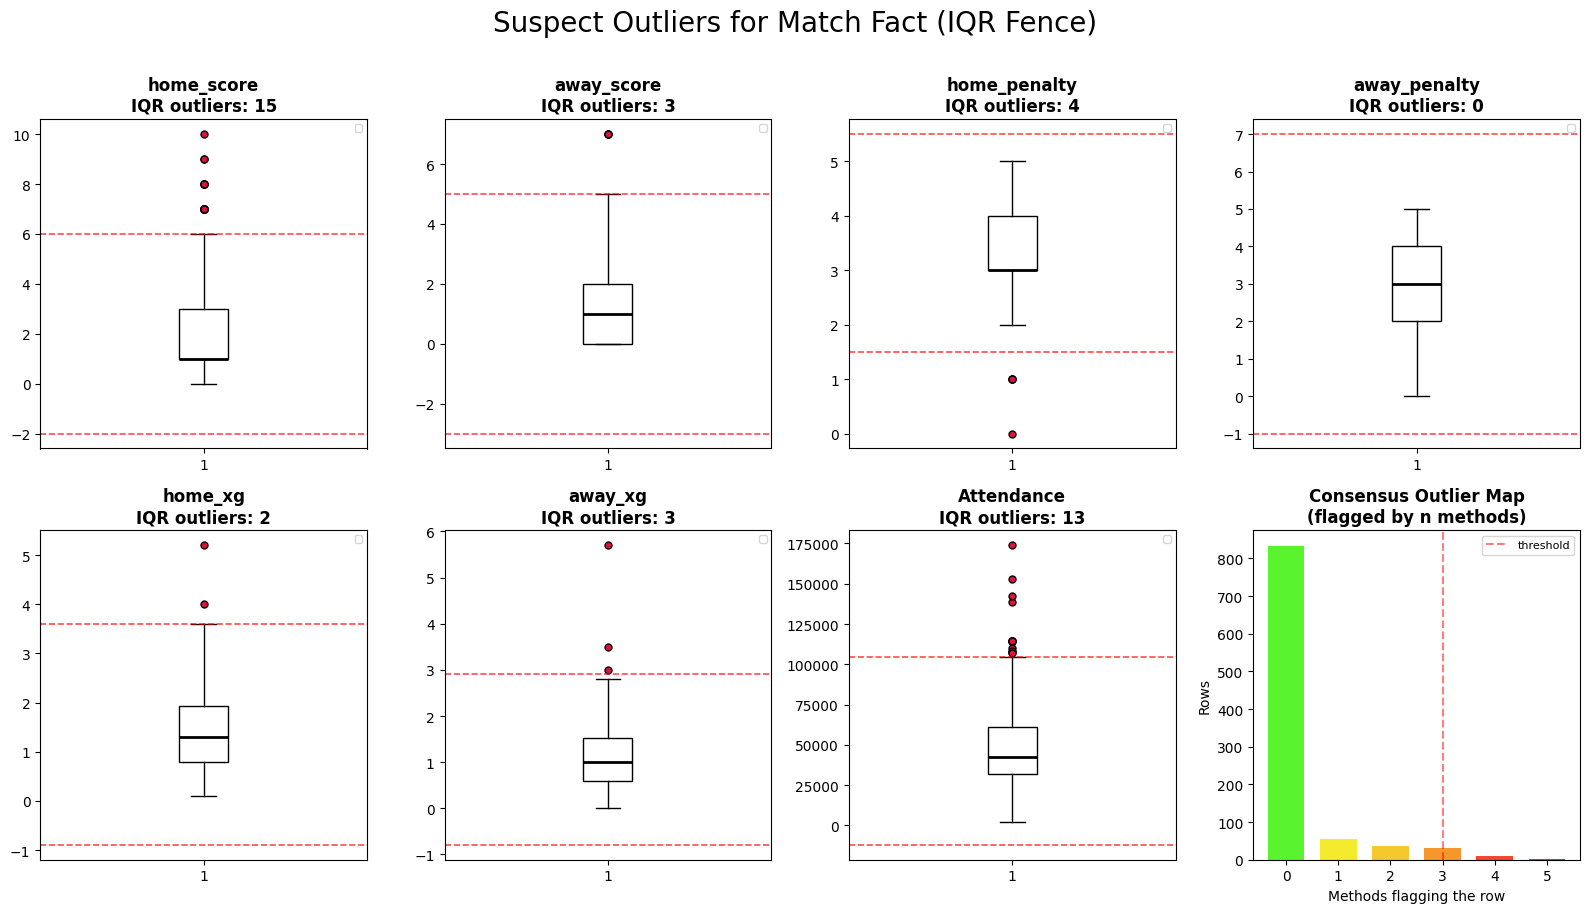

In [12]:
if __name__ == "__main__":
  fig, axes = plt.subplots(2, 4, figsize=(16, 9))

  for i, col in enumerate(measures):
      ax = axes[i // 4][i % 4]
      dat = df_match[col].dropna()
      bp = ax.boxplot(
          dat,
          vert=True,
          patch_artist=True,
          boxprops=dict(facecolor='white', color='black'),
          medianprops=dict(color='black', linewidth=2),
          flierprops=dict(marker='o', markerfacecolor='crimson',
                          markersize=5, alpha=1)
      )

      if col in od_match.results['iqr']['details']:
          det = od_match.results['iqr']['details'][col]

          ax.axhline(
              det['upper_fence'],
              color='red',
              linestyle='--',
              alpha=0.7,
              linewidth=1.2
          )

          ax.axhline(
              det['lower_fence'],
              color='red',
              linestyle='--',
              alpha=0.7,
              linewidth=1.2
          )

          n_out = det['outlier_count']

          ax.set_title(
              f'{col}\nIQR outliers: {n_out}',
              fontweight='bold'
          )

      else:
          ax.set_title(col, fontweight='bold')

      ax.legend(fontsize=7)

  ax_cons = axes[1][3]
  count = od_match.flags.sum(axis=1)
  palette = ['#59f42e','#f4ea2e','#f4c92e','#f4982e','#f4482e','#f42e2e']
  bin_vals = sorted(count.unique())
  counts_per_bin = [int((count == v).sum()) for v in bin_vals]
  bar_colors = [palette[min(v, len(palette)-1)] for v in bin_vals]
  ax_cons.bar(bin_vals, counts_per_bin, color=bar_colors, width=0.7, align='center')
  ax_cons.set_xlabel('Methods flagging the row')
  ax_cons.set_ylabel('Rows')
  ax_cons.set_title('Consensus Outlier Map\n(flagged by n methods)', fontweight='bold')
  ax_cons.axvline(3, color='red', linestyle='--', alpha=0.5, label='threshold')
  ax_cons.legend(fontsize=8)

  plt.suptitle(
      'Suspect Outliers for Match Fact (IQR Fence)',
      fontsize=20,
      y=1.01
  )
  plt.tight_layout()

  fig_output_path = BASE_PATH + '/matches_outlier_detection.png'
  plt.savefig(fig_output_path, bbox_inches='tight', dpi=120)
  plt.show()

According to the consensus strategy, there are 41 rows with outliers. To see if those are really outliers or values that can be obtained in a football match, we can perform some checks

In [13]:
#For each outlier in home_score, let's check if it is consistent, that is if effectively in that match the home nation scored 6 or more goals
home_outliers=df_match[df_match['home_score'] > 6]
descriptions=home_outliers[['home_goal_long']] #description of the home goals happened in the match, it should contain at least 6 goals
descriptions


,home_goal_long
54,"['11&rsquor;|1:0|Dani Olmo', '21&rsquor;|2:0|M..."
224,"['29&rsquor;|1:0|Raul Meireles', '53&rsquor;|2..."
382,"['20&rsquor;|1:0|Miroslav Klose', '25&rsquor;|..."
651,"['4&rsquor;|1:0|Tibor Nyilasi', '11&rsquor;|2:..."
721,"['8&rsquor;|1:0|Dušan Bajević', '14&rsquor;|2:..."
861,"['24&rsquor;|1:1|Just Fontaine', '30&rsquor;|2..."
871,"['7&rsquor;|1:0|Ottmar Walter', '12&rsquor;|2:..."
873,"['3&rsquor;|1:0|Sándor Kocsis', '17&rsquor;|2:..."
874,"['10&rsquor;|1:0|Suat Mamat', '18&rsquor;|2:0|..."
877,"['17&rsquor;|1:0|Carlos Borges', '30&rsquor;|2..."


All the rows where home_score could have been an outlier actually correspond to a match where the home nation has scored 6 or more goals. As can be seen below, the same applies for away_score, except that the fence is 5.

In [14]:
away_outliers=df_match[df_match['away_score'] > 5]
descriptions_a=away_outliers[['away_goal_long']] #description of the away goals happened in the match. It should contain at least 5 goals
descriptions_a

,away_goal_long
131,['11&rsquor;|0:1|Thomas Müller|Assist:|Toni Kr...
716,"['17&rsquor;|0:1|Grzegorz Lato', '18&rsquor;|0..."
870,"['25&rsquor;|3:1|Theodor Wagner', '26&rsquor;|..."


Similarly, also for the home_penalty field we can check the description and see that it corresponds to a match where the home nation scored at most 1 goal in the penalty shootout. For row 267 the description is NaN, but this is coherent with the fact that the home nation scored 0 goals and thus there is no description of penalty shootout ended in goals, but there is of course the description of missed penalties. Also, the away_penalty for the row has value of 3, further suggesting that the match has ended with penalty shootout, but the home nation missed all its penalties.

There are no outliers in away_penalty according to IQR Fence, but if they were similar reasonings could have been applied.

In [15]:
home_pen_outliers=df_match[df_match['home_penalty'] < 2]
descriptions_hp=home_pen_outliers[['home_penalty', 'away_penalty', 'home_penalty_shootout_goal_long', 'home_penalty_shootout_miss_long']]
descriptions_hp

,home_penalty,away_penalty,home_penalty_shootout_goal_long,home_penalty_shootout_miss_long
10,1.000,3.000,['5|1:2|Takuma Asano'],"['1|0:0|Takumi Minamino', '3|0:1|Kaoru Mitoma'..."
260,1.000,3.000,['4|1:1|Owen Hargreaves'],"['2|0:1|Frank Lampard', '6|1:1|Steven Gerrard'..."
267,0.000,3.000,NaN,"['2|0:0|Marco Streller', '4|0:1|Tranquillo Bar..."
457,1.000,3.000,['7|1:2|Claudio Suárez'],"['1|0:0|Alberto García Aspe', '3|0:0|Marcelino..."


Also in the Attendance column there are no outliers, since the outliers value are in rows that actually correspond to a few, very relevant, matches (including two finals and three matches of the final stage of 1950, an edition that has not a "Final" match). One can say that a group stage match it's not so relevant, but all of the group stage matches with an attendance value over the IQR Fence are matches of the Host nation, thus it's likely that more people went to see them.
Further suggesting that there are no outliers is the fact that there are only two venues in all rows, the Estadio Azteca in Mexico City and the Maracanã Stadium in Brazil, which were originally built to have a maximum capability of over 100000 people.

In [16]:
highest_attendance_matches=df_match[df_match['Attendance'] > 104761.25]
highest_attendance_matches[['home_team','away_team','Date','Round','Venue','Host','Attendance']]

,home_team,away_team,Date,Round,Venue,Host,Attendance
552,Argentina,West Germany,1986-06-29,Final,"Estadio Azteca, Mexico City",Mexico,114600
555,Argentina,Belgium,1986-06-25,Semi-finals,"Estadio Azteca, Mexico City",Mexico,114500
556,Argentina,England,1986-06-22,Quarter-finals,"Estadio Azteca, Mexico City",Mexico,114580
566,Mexico,Bulgaria,1986-06-15,Round of 16,"Estadio Azteca, Mexico City",Mexico,114580
583,Mexico,Paraguay,1986-06-07,Group stage,"Estadio Azteca, Mexico City",Mexico,114600
595,Belgium,Mexico,1986-06-03,Group stage,"Estadio Azteca, Mexico City",Mexico,110000
732,Brazil,Italy,1970-06-21,Final,"Estadio Azteca, Mexico City",Mexico,107412
740,Mexico,Belgium,1970-06-11,Group stage,"Estadio Azteca, Mexico City",Mexico,108192
763,Mexico,Soviet Union,1970-05-31,Group stage,"Estadio Azteca, Mexico City",Mexico,107160
890,Uruguay,Brazil,1950-07-16,Final stage,Maracanï¿½ - Estï¿½dio Jornalista Mï¿½rio Filh...,Brazil,173850
